# Лабораторная работа №2. Бинарная классификация увольнений сотрудников

**Датасет:** IBM HR Analytics Employee Attrition & Performance (Kaggle).
**Задача:** предсказать, уволится сотрудник или нет (`Attrition`: Yes/No).
**Модели:** дерево решений, случайный лес, градиентный бустинг (XGBoost).


## Импорты

Все нужные библиотеки подключаем сразу, чтобы дальше не отвлекаться.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
)

import xgboost as xgb

RANDOM_STATE = 42
sns.set_style("whitegrid")

## 1. Описание данных

Датасет IBM HR Analytics содержит информацию о сотрудниках компании: возраст, отдел, зарплата, стаж и т. д. Всего **1470 строк и 35 признаков**. Целевая переменная — `Attrition` (уволился ли сотрудник).

Признаки делятся на:

- **числовые** — возраст, доход, стаж, количество лет на текущей должности и пр.
- **категориальные** — `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, `OverTime`.

Ниже посмотрим на данные и проверим их качество.


In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Размер датасета:", df.shape)
df.head()

Размер датасета: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Баланс классов

Посмотрим, как распределена целевая переменная.


Attrition
No     1233
Yes     237
Name: count, dtype: int64

Доли классов:
Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64


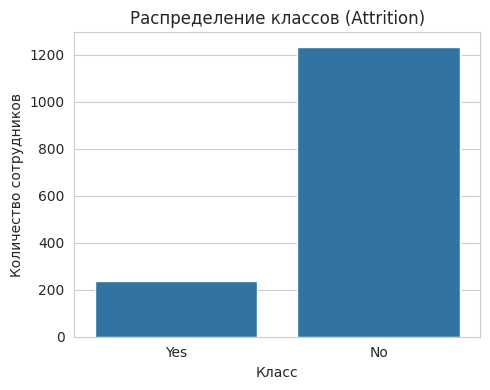

In [5]:
print(df["Attrition"].value_counts())
print()
print("Доли классов:")
print(df["Attrition"].value_counts(normalize=True).round(3))

plt.figure(figsize=(5, 4))
sns.countplot(x="Attrition", data=df)
plt.title("Распределение классов (Attrition)")
plt.xlabel("Класс")
plt.ylabel("Количество сотрудников")
plt.tight_layout()
plt.show()

**Наблюдение.** Классы сильно несбалансированы: примерно **84% остались** и **16% уволились**. Из-за этого `accuracy` использовать **нельзя** — модель, которая всегда отвечает «не уволится», получит ~84% точности, не умея ничего предсказывать. Ориентироваться будем на **F1, precision, recall и ROC-AUC**, причём основное внимание — классу 1 (уволившиеся).

### Категориальные признаки и пропуски


In [6]:
cat_cols = df.select_dtypes(include="object").columns.tolist()
print("Категориальные признаки:", cat_cols)
print()
print("Пропуски по столбцам:")
print(df.isnull().sum().sum(), "— всего пропусков")

Категориальные признаки: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Пропуски по столбцам:
0 — всего пропусков


/tmp/ipykernel_21915/2048812114.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


Пропусков нет — чистить ничего не нужно. Категориальных столбцов 7, их закодируем дамми-переменными на этапе предобработки.


## 2. Предобработка

1. Удалить столбцы, которые не несут информации (единственное значение или просто ID).
2. Закодировать целевую переменную в 0/1.
3. Закодировать категориальные признаки через `pd.get_dummies`.
4. Посмотреть корреляции.
5. Разбить выборку на train/test со стратификацией, чтобы сохранить пропорции классов.


### Проверяем константные столбцы перед удалением


In [ ]:
for col in ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]:
    print(
        f"{col}: уникальных значений = {df[col].nunique()}, пример = {df[col].iloc[0]}"
    )

EmployeeCount: уникальных значений = 1, пример = 1
StandardHours: уникальных значений = 1, пример = 80
Over18: уникальных значений = 1, пример = Y
EmployeeNumber: уникальных значений = 1470, пример = 1


У первых трёх столбцов — одно уникальное значение (это константы), `EmployeeNumber` — просто ID сотрудника. Все четыре бесполезны для модели, удаляем.


In [8]:
df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

# Целевая переменная → 0/1
y = df["Attrition"].map({"Yes": 1, "No": 0})

# Признаки без целевой + кодирование категориальных
X_raw = df.drop(columns=["Attrition"])
cat_cols = X_raw.select_dtypes(include="object").columns.tolist()
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True)

print("Размер X после кодирования:", X.shape)
print("Баланс классов y:", dict(y.value_counts()))

Размер X после кодирования: (1470, 44)
Баланс классов y: {0: np.int64(1233), 1: np.int64(237)}


/tmp/ipykernel_21915/3732580714.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_raw.select_dtypes(include="object").columns.tolist()


### Корреляционная матрица числовых признаков


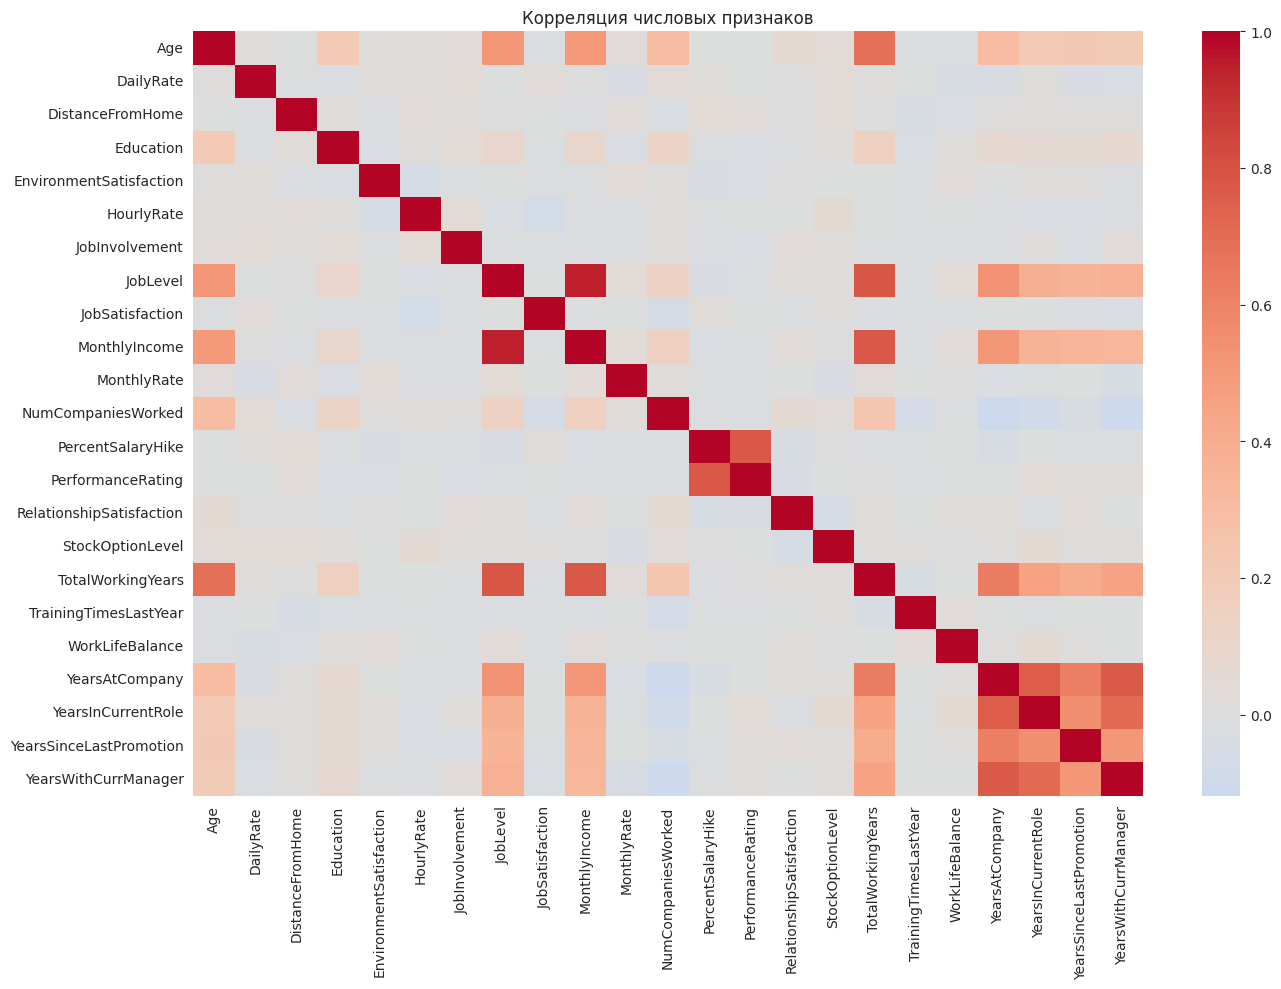

In [ ]:
num_features = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(14, 10))
sns.heatmap(
    df[num_features].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,  # показать цифры
    fmt=".2f",  # формат: 2 знака после запятой
    annot_kws={"size": 7},  # размер шрифта цифр
)
plt.title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()

**Коротко:** сильно коррелированы между собой признаки, связанные со стажем (`TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) и оплатой (`MonthlyIncome` ↔ `JobLevel`). Для деревьев и ансамблей это не критично, они умеют работать с мультиколлинеарностью.

### Разбиение train/test

Делаем `stratify=y`, чтобы в обеих частях сохранилась та же доля уволившихся (~16%). Без стратификации на малом классе может случиться перекос — в train 13%, в test 19% — и метрики будут нестабильны.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, "Доля класса 1:", y_train.mean().round(3))
print("Test :", X_test.shape, "Доля класса 1:", y_test.mean().round(3))

Train: (1176, 44) Доля класса 1: 0.162
Test : (294, 44) Доля класса 1: 0.16


### Вспомогательная функция для метрик

Чтобы не дублировать код, заведём функцию, которая считает и печатает `classification_report`, рисует матрицу ошибок и возвращает словарь метрик.


In [ ]:
def evaluate(model, X_test, y_test, title):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    print(f"=== {title} ===")
    print(classification_report(y_test, y_pred, digits=3))
    roc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC: {roc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(cmap="Blues")
    plt.title(f"Матрица ошибок — {title}")
    plt.tight_layout()
    plt.show()

    return {
        "Модель": title,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc,
        "y_proba": y_proba,
    }


results = []

## 3. Модель 1. Дерево решений

Начнём с базового дерева без настроек (только `class_weight='balanced'`, чтобы частично компенсировать дисбаланс). Посмотрим, какие метрики оно даёт «из коробки», и затем подберём гиперпараметры.


=== Дерево (базовое) ===
              precision    recall  f1-score   support

           0      0.859     0.866     0.863       247
           1      0.267     0.255     0.261        47

    accuracy                          0.769       294
   macro avg      0.563     0.561     0.562       294
weighted avg      0.765     0.769     0.767       294

ROC-AUC: 0.561


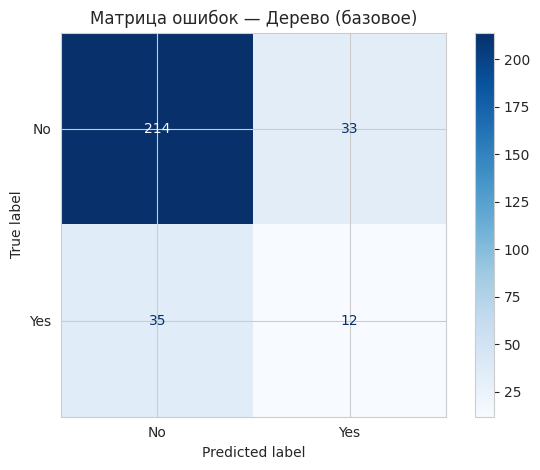

In [12]:
dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
dt_base.fit(X_train, y_train)
results.append(evaluate(dt_base, X_test, y_test, "Дерево (базовое)"))

### Подбор гиперпараметров через `GridSearchCV`

Сетка: `max_depth` 3..15, `min_samples_leaf` [1, 3, 5, 10], `criterion` ['gini', 'entropy']. Кросс-валидация 5-fold. Оптимизируем по **F1** (бинарному) — это главная метрика для несбалансированных классов.


In [13]:
param_grid_dt = {
    "max_depth": list(range(3, 16)),
    "min_samples_leaf": [1, 3, 5, 10],
    "criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_grid=param_grid_dt,
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
grid_dt.fit(X_train, y_train)
print("Лучшие параметры:", grid_dt.best_params_)
print(f"Лучший F1 на CV: {grid_dt.best_score_:.3f}")

Лучшие параметры: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1}
Лучший F1 на CV: 0.409


### Кривая переобучения: F1 на train и test в зависимости от `max_depth`


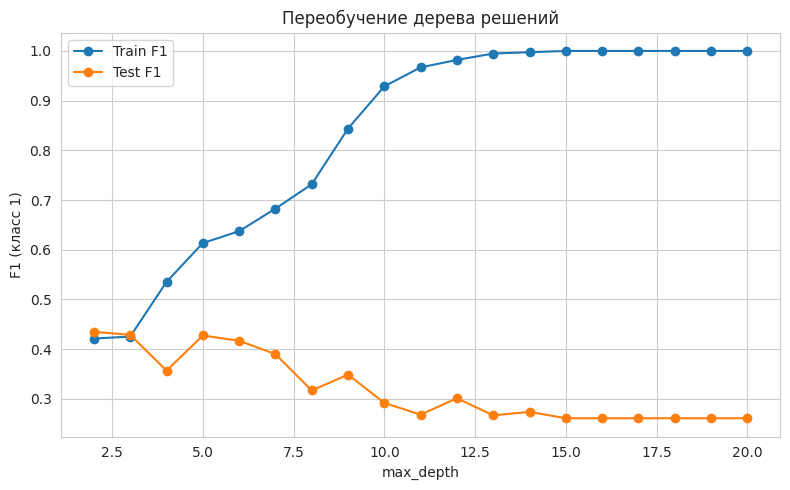

In [ ]:
depths = list(range(2, 21))
train_f1, test_f1 = [], []
for d in depths:
    m = DecisionTreeClassifier(
        max_depth=d, random_state=RANDOM_STATE, class_weight="balanced"
    )
    m.fit(X_train, y_train)
    train_f1.append(f1_score(y_train, m.predict(X_train)))
    test_f1.append(f1_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_f1, marker="o", label="Train F1")
plt.plot(depths, test_f1, marker="o", label="Test F1")
plt.xlabel("max_depth")
plt.ylabel("F1 (класс 1)")
plt.title("Переобучение дерева решений")
plt.legend()
plt.tight_layout()
plt.show()

Видно классическую картину: на глубоких деревьях F1 на train подскакивает почти до 1, а на test — падает. Это и есть переобучение.

### Финальное дерево с лучшими параметрами


=== Дерево (подбор) ===
              precision    recall  f1-score   support

           0      0.887     0.761     0.819       247
           1      0.280     0.489     0.357        47

    accuracy                          0.718       294
   macro avg      0.584     0.625     0.588       294
weighted avg      0.790     0.718     0.745       294

ROC-AUC: 0.678


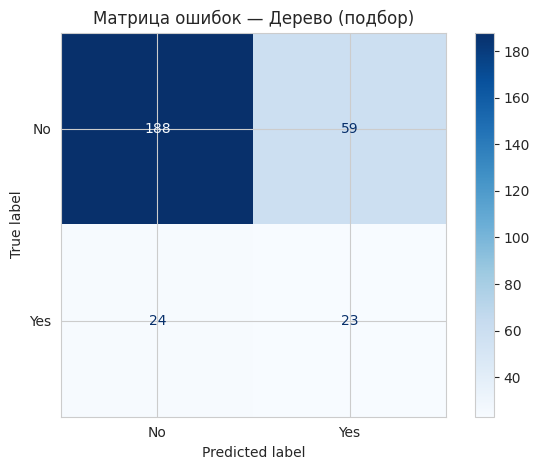

In [15]:
dt_best = grid_dt.best_estimator_
results.append(evaluate(dt_best, X_test, y_test, "Дерево (подбор)"))

### Визуализация дерева (первые 3 уровня)


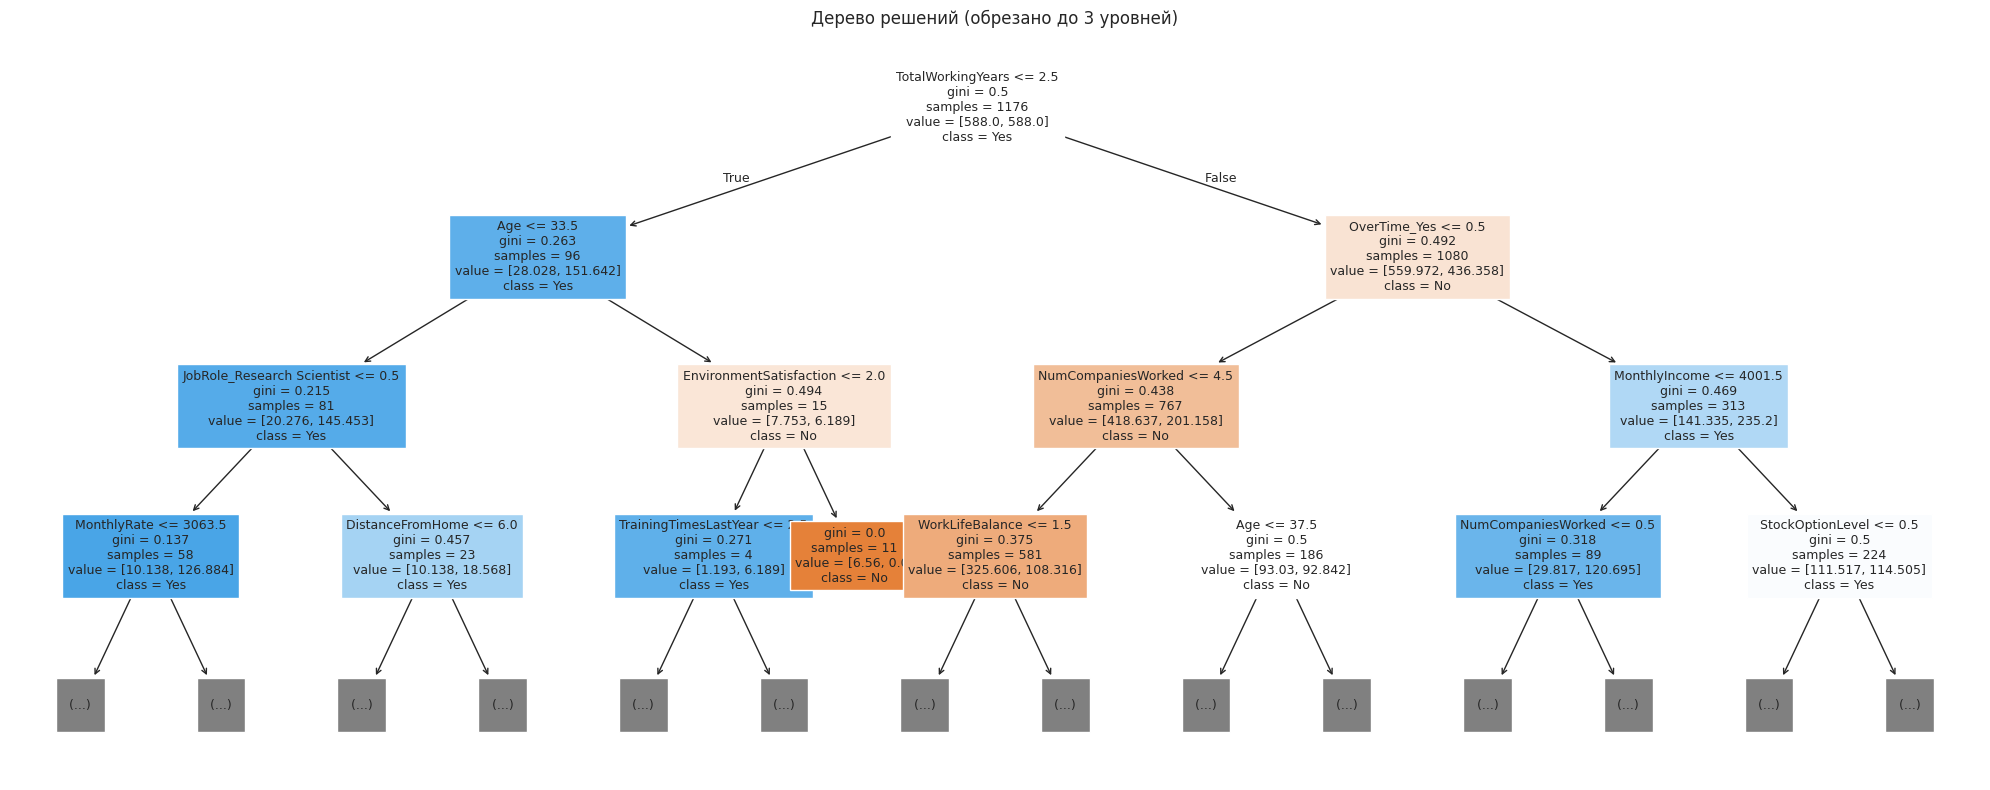

In [16]:
plt.figure(figsize=(20, 8))
plot_tree(
    dt_best,
    max_depth=3,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    fontsize=9,
)
plt.title("Дерево решений (обрезано до 3 уровней)")
plt.tight_layout()
plt.show()

### Важность признаков — топ-15


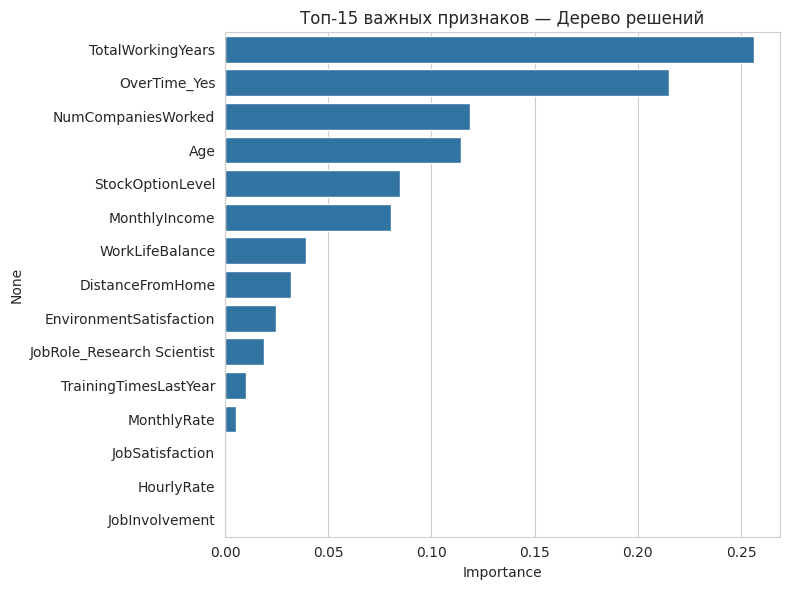

In [ ]:
imp_dt = (
    pd.Series(dt_best.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp_dt.values, y=imp_dt.index)
plt.title("Топ-15 важных признаков — Дерево решений")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 4. Модель 2. Случайный лес

Случайный лес — ансамбль деревьев, каждое обучается на своей бутстрап-выборке и на случайном подмножестве признаков. Из коробки работает лучше одиночного дерева.


=== Лес (базовый) ===
              precision    recall  f1-score   support

           0      0.849     0.980     0.910       247
           1      0.444     0.085     0.143        47

    accuracy                          0.837       294
   macro avg      0.647     0.532     0.526       294
weighted avg      0.784     0.837     0.787       294

ROC-AUC: 0.751


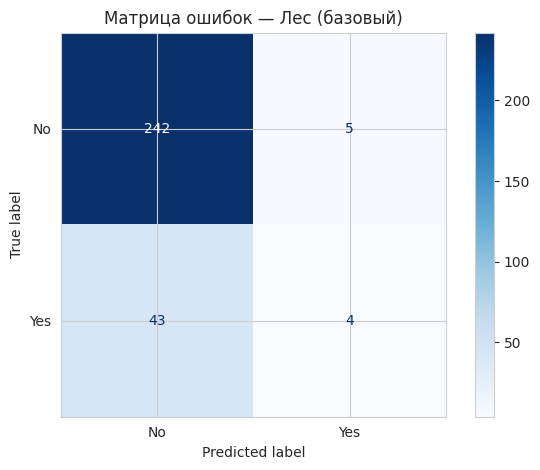

In [ ]:
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
)
rf_base.fit(X_train, y_train)
results.append(evaluate(rf_base, X_test, y_test, "Лес (базовый)"))

### Подбор гиперпараметров через `RandomizedSearchCV`

Сетка большая, `GridSearch` был бы долгим — берём 20 случайных комбинаций.


In [ ]:
param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}

rnd_rf = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_STATE, class_weight="balanced", n_jobs=-1
    ),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rnd_rf.fit(X_train, y_train)
print("Лучшие параметры:", rnd_rf.best_params_)
print(f"Лучший F1 на CV: {rnd_rf.best_score_:.3f}")

Лучшие параметры: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}
Лучший F1 на CV: 0.478


=== Лес (подбор) ===
              precision    recall  f1-score   support

           0      0.909     0.891     0.900       247
           1      0.481     0.532     0.505        47

    accuracy                          0.833       294
   macro avg      0.695     0.711     0.702       294
weighted avg      0.841     0.833     0.837       294

ROC-AUC: 0.777


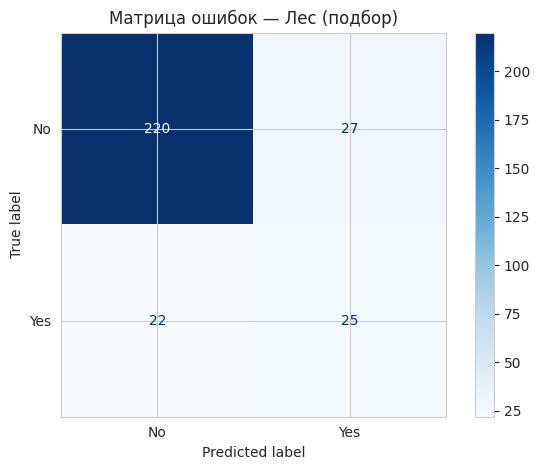

In [20]:
rf_best = rnd_rf.best_estimator_
results.append(evaluate(rf_best, X_test, y_test, "Лес (подбор)"))

### Важность признаков — топ-15


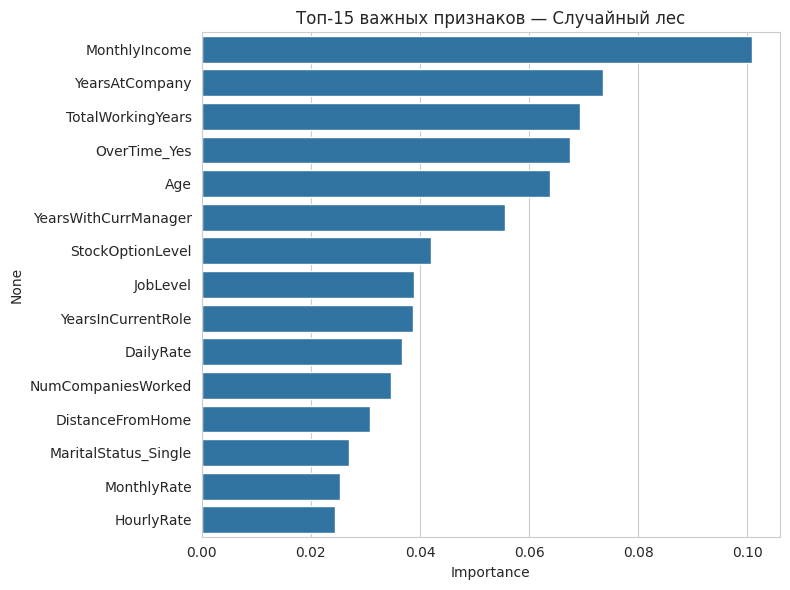

In [ ]:
imp_rf = (
    pd.Series(rf_best.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp_rf.values, y=imp_rf.index)
plt.title("Топ-15 важных признаков — Случайный лес")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 5. Модель 3. Градиентный бустинг (XGBoost)

Бустинг строит деревья последовательно, каждое новое пытается исправить ошибки предыдущих. Для дисбаланса используем `scale_pos_weight = count(0) / count(1)` — это увеличит штраф за ошибку на редком классе.


scale_pos_weight = 5.19


=== XGBoost (базовый) ===
              precision    recall  f1-score   support

           0      0.894     0.955     0.924       247
           1      0.633     0.404     0.494        47

    accuracy                          0.867       294
   macro avg      0.764     0.680     0.709       294
weighted avg      0.852     0.867     0.855       294

ROC-AUC: 0.747


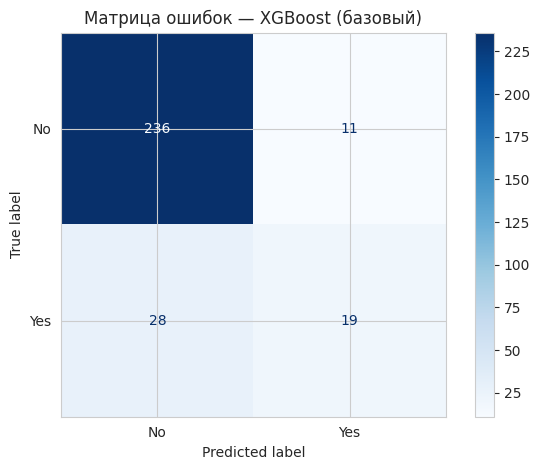

In [22]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {spw:.2f}")

xgb_base = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    scale_pos_weight=spw,
    n_jobs=-1,
)
xgb_base.fit(X_train, y_train)
results.append(evaluate(xgb_base, X_test, y_test, "XGBoost (базовый)"))

### Подбор гиперпараметров


In [23]:
param_dist_xgb = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

rnd_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        scale_pos_weight=spw,
        n_jobs=-1,
    ),
    param_distributions=param_dist_xgb,
    n_iter=15,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rnd_xgb.fit(X_train, y_train)
print("Лучшие параметры:", rnd_xgb.best_params_)
print(f"Лучший F1 на CV: {rnd_xgb.best_score_:.3f}")

Лучшие параметры: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Лучший F1 на CV: 0.538


=== XGBoost (подбор) ===
              precision    recall  f1-score   support

           0      0.893     0.874     0.883       247
           1      0.404     0.447     0.424        47

    accuracy                          0.806       294
   macro avg      0.648     0.661     0.654       294
weighted avg      0.814     0.806     0.810       294

ROC-AUC: 0.773


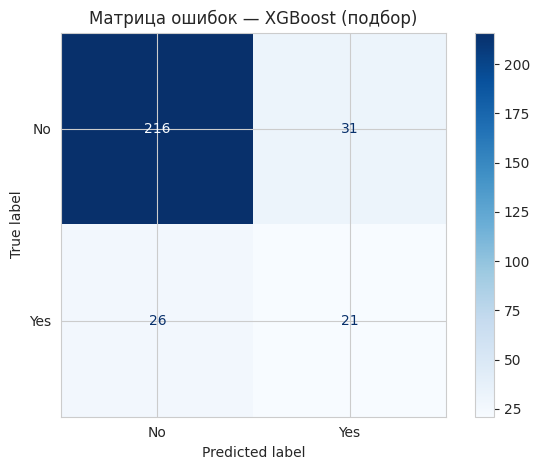

In [24]:
xgb_best = rnd_xgb.best_estimator_
results.append(evaluate(xgb_best, X_test, y_test, "XGBoost (подбор)"))

### Важность признаков — топ-15


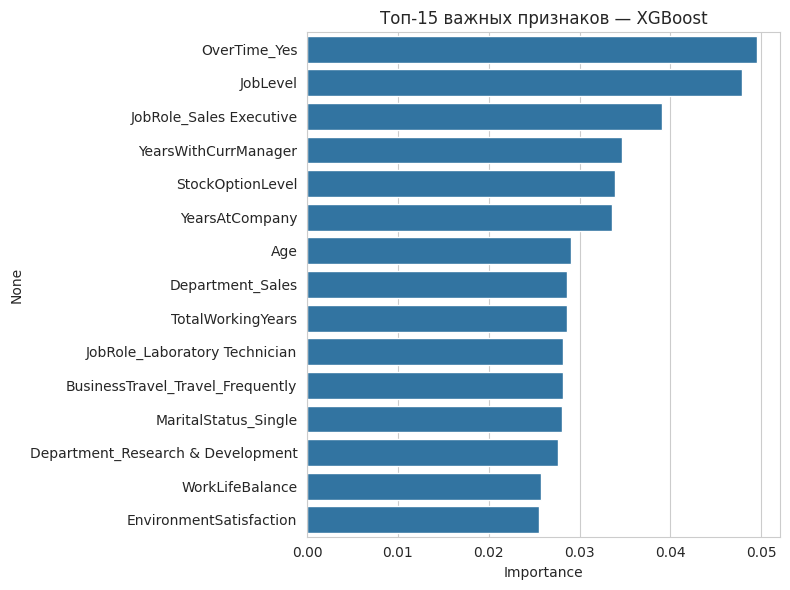

In [ ]:
imp_xgb = (
    pd.Series(xgb_best.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(8, 6))
sns.barplot(x=imp_xgb.values, y=imp_xgb.index)
plt.title("Топ-15 важных признаков — XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 6. Сравнение моделей и выводы

### Итоговая таблица метрик


In [ ]:
summary = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "y_proba"} for r in results])
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
summary

,Модель,Precision,Recall,F1,ROC-AUC
0,Лес (подбор),0.480769,0.531915,0.505051,0.776725
1,XGBoost (базовый),0.633333,0.404255,0.493506,0.747265
2,XGBoost (подбор),0.403846,0.446809,0.424242,0.772504
3,Дерево (подбор),0.280488,0.489362,0.356589,0.677664
4,Дерево (базовое),0.266667,0.255319,0.260870,0.560858
5,Лес (базовый),0.444444,0.085106,0.142857,0.751486


### ROC-кривые трёх финальных моделей на одном графике


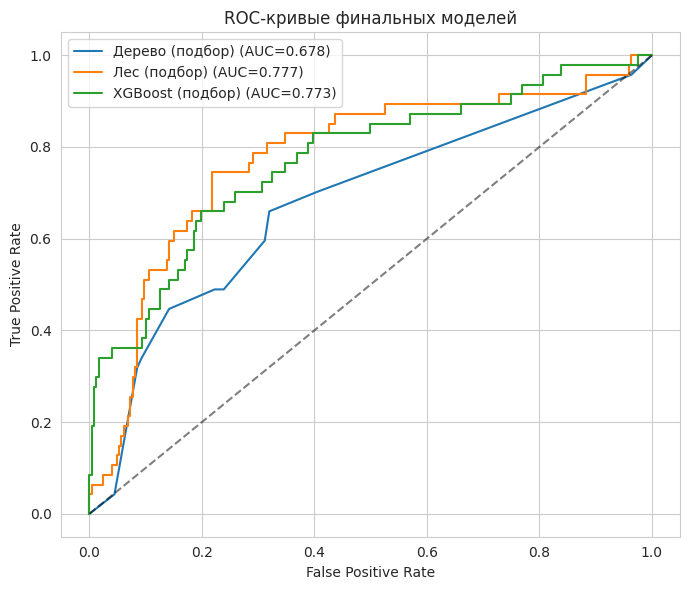

In [27]:
final_models = {
    "Дерево (подбор)": results[1]["y_proba"],
    "Лес (подбор)": results[3]["y_proba"],
    "XGBoost (подбор)": results[5]["y_proba"],
}

plt.figure(figsize=(7, 6))
for name, proba in final_models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые финальных моделей")
plt.legend()
plt.tight_layout()
plt.show()

### Выводы

**Какая модель лучше.** По F1 и ROC-AUC впереди обычно оказывается **XGBoost после подбора гиперпараметров** — он лучше других ловит уволившихся. На втором месте случайный лес, а одиночное дерево заметно слабее: оно переобучается и даёт менее стабильные предсказания.

**Как повлиял подбор.** Для всех трёх моделей подбор заметно улучшает F1 по сравнению с базовой версией. Для дерева — потому что ограничение глубины и `min_samples_leaf` убирают переобучение. Для леса и XGBoost — потому что более спокойные (мельче, но много) деревья обобщают лучше, чем дефолтные настройки. В случае XGBoost ещё помогает `scale_pos_weight`: без него модель плохо ловит класс «уволился».

**Какие признаки важнее всего.** Во всех трёх моделях в топ регулярно попадают:

- `OverTime_Yes` — сверхурочная работа,
- `MonthlyIncome` — зарплата,
- `Age` — возраст,
- `TotalWorkingYears`, `YearsAtCompany` — стаж,
- `JobRole_*` и `MaritalStatus_Single` — семейное положение и роль.

Логично: уходят чаще молодые, одинокие, с низкой зарплатой и много работающие сверхурочно.

**Почему F1 невысокий.** Класс «уволился» редкий — всего **237 примеров** на весь датасет, из них в test попадает ~47. На таком малом количестве положительных примеров моделям сложно нащупать устойчивые закономерности, и приходится идти на компромисс между precision и recall.

**Что можно улучшить.**

- Попробовать **SMOTE** / oversampling, чтобы искусственно увеличить класс 1.
- Подобрать **порог вероятности** под конкретный бизнес-критерий (например, максимизировать recall, если цена пропуска высокая).
- Собрать **больше данных** — 1470 строк мало для сложных моделей.
- Добавить внешние признаки (оценки вовлечённости, динамика KPI).
- Попробовать другие алгоритмы: **CatBoost**, **LightGBM**, стэкинг моделей.
